# Module 1 — From Particles to Sets: **DeepSets, PFN & EFN**
### TIFR ML School 2026 · *Sets, Graphs & Symmetry for High-Energy Physics*

This is the **first** module of the course. Its single goal is to make one idea concrete:

> A jet (or an event) is a **set** of particles — a *variable-length, unordered* collection of
> 4-vectors. The right first tool for such data is **DeepSets**, and its HEP incarnations the
> **Particle Flow Network (PFN)** and **Energy Flow Network (EFN)**.

Everything later in the course (graphs, attention, equivariant nets, hypergraphs) is built by
*adding one ingredient* to what we do here. The permutation-invariant **aggregation** you meet in
this notebook is the atom of the entire course.

**What you will do, end-to-end:**
1. Define permutation **invariance / equivariance** and state the **Deep Sets theorem**.
2. Implement the DeepSets building blocks **from scratch** and *numerically verify* the symmetry.
3. Warm up on a toy: classify **images turned into point clouds**, and *prove* the model ignores point order.
4. Train a **PFN** to tag **top vs QCD** jets on real JetClass data; evaluate with **ROC / AUC / background rejection**.
5. Train an **EFN** and *demonstrate its infrared-&-collinear (IRC) safety* — a physics guarantee baked into the architecture.

**Dependencies:** `numpy torch torchvision matplotlib scikit-learn uproot awkward`.
Note there is **no** `torch_geometric` here — graphs start in Module 2.

## 1 · Why *sets* in high-energy physics?

A reconstructed jet is a list of particles $\{p_1, p_2, \dots, p_N\}$. Two facts make it awkward for
ordinary deep learning:

- **Variable length.** Different jets have different numbers of particles $N$. A plain MLP wants a
  fixed-size input; a CNN wants a grid; an RNN wants an order.
- **No intrinsic order.** The particles carry *no canonical ordering*. If I shuffle the list, it is the
  **same jet** and the physics answer (is this a top quark? what is the mass?) must not change.

The property we need is **permutation invariance** of the network's output. Baking this symmetry in as an
*inductive bias* — rather than hoping the model learns it from data — gives better accuracy, fewer
parameters, and guarantees that hold for *every* input, not just the training set.

This is exactly what **DeepSets** provides.

In [1]:
%matplotlib inline
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

# Pick the best available device (CUDA > Apple-MPS > CPU). We stay in float32 everywhere
# (MPS does not support float64 — a common gotcha in older HEP notebooks).
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("Using device:", device)

Using device: mps


## 2 · Permutation invariance and equivariance

Let a set of $N$ points be the rows of a matrix $X \in \mathbb{R}^{N\times C}$ (each row is one particle's
$C$ features). A permutation $\pi$ of the points acts by a permutation matrix $P$ (a shuffled identity),
sending $X \mapsto PX$.

A function $f$ is **permutation-invariant** if reshuffling the input leaves the output unchanged:
$$ f(PX) = f(X) \qquad\text{for every permutation } P . $$
This is what we want for a **whole-jet** prediction (class, mass, ...).

A layer $L$ is **permutation-equivariant** if reshuffling the input reshuffles the output *the same way*:
$$ L(PX) = P\,L(X) . $$
This is what we want for **per-particle** outputs (so we can stack several such layers and only pool at the end).

The recipe for an invariant network is therefore: **stack equivariant layers, then apply one invariant pool.**

## 3 · The Deep Sets theorem (Zaheer et al., 2017)

**Theorem (informal).** A function $f$ acting on a set $\{x_1,\dots,x_N\}$ is permutation-invariant *and*
can be approximated arbitrarily well **iff** it has the form
$$ \boxed{\; f(\{x_i\}) \;=\; \rho\!\Big( \textstyle\sum_{i=1}^{N} \phi(x_i) \Big) \;} $$
for suitable functions $\phi$ (applied to each point) and $\rho$ (applied to the pooled vector).

Read it as three steps:
1. **Embed** every particle independently: $h_i = \phi(x_i)$ — this step is permutation-*equivariant*.
2. **Pool** with a symmetric operation: $z = \sum_i h_i$ — this step makes it permutation-*invariant*.
3. **Decode** the summary: $\text{out} = \rho(z)$.

The **sum** is the canonical pool (the theorem is proved with it). `mean` and `max` are also invariant and
often work well, but they can lose information the sum keeps — e.g. `mean` forgets the multiplicity $N$,
`max` forgets everything except the extremes. We will use `sum`/`mean` and leave `max` to an exercise.

> In HEP this *is* the **Particle Flow Network**: $\phi$ = per-particle MLP, sum-pool, $\rho$ = classifier MLP.

## 4 · Two ways to build a DeepSet

**(a) The canonical invariant form** — $\rho(\sum_i \phi(x_i))$ — is what we will train. It maps directly onto PFN.

**(b) The equivariant *linear* layer.** It is illuminating to see the most general permutation-equivariant
*linear* map. With $\gamma,\lambda\in\mathbb{R}$ it is $x' = \gamma\, x + \lambda\,(\mathbb{1}\mathbb{1}^{\!\top})x$,
i.e. each output point mixes "itself" with "the sum of all points". Writing it with learnable weight
matrices $\Gamma,\Lambda$ and centring by the mean:
$$ x' \;=\; \Gamma\, x \;+\; \Lambda\,\big(x - \operatorname{mean}_i x\big) . $$
The first term is point-wise; the second couples every point to the set average — and *that coupling is
what makes the layer aware of the whole set while staying equivariant*. Stacking these (with
nonlinearities) and pooling at the end is an equivalent route to an invariant network.

Below we implement both, and in the next cell we **numerically check** the equivariance of (b).

In [2]:
# Define a function to automatically build a neural network.
# It takes the input size, a list of hidden layer sizes, the final output size, and defaults to ReLU for the activation function.
def make_mlp(in_dim, hidden, out_dim, act=nn.ReLU):
    """A small helper: MLP with ReLU between layers. Works on tensors shaped (..., in_dim);
    nn.Linear acts on the last dimension, so the SAME MLP is applied independently to every
    particle when the input is (B, N, in_dim)."""

    # Combine the input dimension with the list of hidden dimensions.
    # The asterisk (*hidden) unpacks the list so it becomes a single flat list.
    # E.g., if in_dim=7 and hidden=[64, 128], dims becomes [7, 64, 128].
    dims = [in_dim, *hidden]

    # Initialize an empty list that will physically hold our PyTorch layers
    layers = []

    # The zip function pairs up adjacent elements in the 'dims' list to define the input/output sizes of each layer.
    # For [7, 64, 128], zip pairs them as: (7, 64) then (64, 128).
    for a, b in zip(dims[:-1], dims[1:]):
        # For each pair, append a Linear layer (matrix multiplication) going from size 'a' to size 'b'.
        # Also append the activation function (act()) to introduce non-linearity so the AI can learn complex patterns.
        layers += [nn.Linear(a, b), act()]

    # After the loop finishes the hidden layers, add one final Linear layer.
    # This connects the very last hidden size (dims[-1]) to your desired final output size (out_dim).
    # Notice we DO NOT add an activation function to this final layer, as we want raw, unconstrained output numbers (logits).
    layers += [nn.Linear(dims[-1], out_dim)]

    # Unpack the list of assembled layers into PyTorch's 'nn.Sequential' container.
    # This officially packages them into a single runnable neural network model where data flows sequentially from start to finish.
    return nn.Sequential(*layers)

# --- masked pooling -------------------------------------------------------------
# Because jets have different N, we pad every set in a batch to the same length and carry a
# 0/1 `mask` (1 = real particle, 0 = padding). The pool MUST ignore padded slots, otherwise
# phi(0) of the padding leaks into the sum. This masking is the #1 source of bugs in the field.


# Define a function that sums up the features of a point cloud while ignoring dummy padding points.
def masked_sum(x, mask):
    # 'x' is our point cloud data shaped (Batch, Particles, Features).
    # 'mask' is our 0/1 cheat sheet shaped (Batch, Particles).

    # Step 1: mask.unsqueeze(-1) adds an extra empty dimension to the mask, changing it from (Batch, Particles) to (Batch, Particles, 1).
    # This is required so PyTorch can mathematically align it with the 3D 'x' tensor.
    # Step 2: (x * mask...) multiplies every feature of a particle by its mask value.
    # Real particles are multiplied by 1 (unchanged). Padded particles are multiplied by 0 (completely erased).
    # Step 3: .sum(dim=1) squashes the particles together, adding them up along the particle dimension (dim=1),
    # leaving us with a single aggregated summary vector per point cloud.
    return (x * mask.unsqueeze(-1)).sum(dim=1)

# Define a function that calculates the average features of a point cloud while ignoring dummy padding points.
def masked_mean(x, mask):

    # Get the clean, safe total sum of all the REAL particles by calling the masked_sum function we just created.
    s = masked_sum(x, mask)

    # Calculate the denominator (how many real particles there actually are).
    # mask.sum(dim=1...) adds up the 1s in the mask to get the true count of real particles.
    # keepdim=True prevents PyTorch from collapsing the dimensions, keeping it aligned for the upcoming division.
    # .clamp(min=1.0) is a crucial safety net: if a point cloud is completely empty, the sum is 0.
    # Clamping forces the minimum count to be 1.0, preventing a fatal "divide by zero" crash in the software.
    n = mask.sum(dim=1, keepdim=True).clamp(min=1.0)

    # Divide the clean sum by the true count of real particles to get the exact average.
    return s / n

In [3]:
# Define a custom PyTorch layer that preserves permutation equivariance.
class DeepSetsEquivariantLayer(nn.Module):
    # Initialize the layer, defining input and output sizes
    def __init__(self, in_features, out_features):
        super().__init__()

        # Gamma: A standard linear layer that processes each particle individually
        self.Gamma = nn.Linear(in_features, out_features)

        # Lambda: A linear layer that processes the difference between a particle and the group mean
        self.Lambda = nn.Linear(in_features, out_features)

    # The forward pass dictates how data flows through this layer
    def forward(self, x):
        # 1. x.mean(dim=1, keepdim=True) calculates the average of all particles in the set.
        # 2. (x - x.mean()) calculates how much each individual particle deviates from that average.
        # 3. We apply Gamma to the raw points, Lambda to the deviations, and add them together.
        return self.Gamma(x) + self.Lambda(x - x.mean(dim=1, keepdim=True))


# Create an instance of our new layer mapping 3 features to 5 features
layer = DeepSetsEquivariantLayer(3, 5)

# Create a fake batch of data: 1 batch, 6 points, 3 features per point
x = torch.randn(1, 6, 3)

# Generate a random shuffled order for our 6 points (e.g., [3, 1, 5, 0, 4, 2])
perm = torch.randperm(6)

# Run the original, unshuffled data through the layer
y = layer(x)

# 'x' is a 3D tensor with dimensions (Batch, N_points, C_features), specifically (1, 6, 3).
# 'perm' is a 1D tensor containing a randomized sequence of indices from 0 to 5, e.g., tensor([2, 5, 0, 1, 4, 3]).

# x[:, perm, :] applies PyTorch "advanced indexing" across the three axes:
#   1. The first ':' keeps all elements in the Batch dimension (dim=0) exactly as they are.
#   2. The 'perm' array broadcasts across the N_points dimension (dim=1). It maps the point at index 'perm[i]' to the new position 'i'.
#   3. The final ':' keeps all C_features (dim=2) perfectly intact and bound to their respective points.
#
# Unlike basic slicing which returns a memory "view", advanced indexing allocates new memory and returns a contiguous copy of the tensor with the points physically rearranged.
#
# Finally, layer(...) passes this newly allocated, spatially reordered tensor through the forward pass of the DeepSetsEquivariantLayer.
y_permuted = layer(x[:, perm, :])

# The Proof:
# Take the baseline output 'y' and shuffle it AFTER processing (y[:, perm, :]).
# Subtract the output where the input was shuffled BEFORE processing (y_permuted).
# .abs().max().item() finds the largest mathematical difference between the two results.
print(
    "max |P f(x) - f(Px)| =",
    (y[:, perm, :] - y_permuted).abs().max().item(),
    "  (should be ~0  =>  equivariant)",
)

max |P f(x) - f(Px)| = 0.0   (should be ~0  =>  equivariant)


In [4]:
# Define the main DeepSets classification model, which maps a variable-length
# set of particle vectors to a fixed-size tensor of class logits.
class DeepSetsClassifier(nn.Module):
    """Canonical Deep Sets / PFN:   out = F( pool_i Phi(x_i) ).
    Phi : per-particle embedding MLP   (equivariant step)
    pool: masked sum or mean           (invariant step)
    F   : classifier head MLP          (decode step)
    """

    # Initialize the architecture dimensions.
    # in_features: Initial dimensionality of each particle (C_in).
    # phi_hidden, latent: Architect the feature-extractor network (Phi).
    # f_hidden, n_classes: Architect the final decoder network (F or Rho).
    def __init__(
        self,
        in_features,
        phi_hidden=(64, 64, 128),
        latent=128,
        f_hidden=(128, 64),
        n_classes=10,
        pool="sum",
    ):
        super().__init__()

        # Store the chosen symmetric pooling operator (typically "sum" or "mean").
        self.pool = pool

        # Construct Phi: The equivariant feature extractor.
        # This Multi-Layer Perceptron (MLP) learns a mapping from R^{C_in} -> R^{latent}.
        # It will be applied identically and independently to every particle.
        self.phi = make_mlp(in_features, phi_hidden, latent)

        # Construct F (\Rho): The invariant decoder.
        # This MLP learns a mapping from R^{latent} -> R^{n_classes}.
        # It takes the pooled, global representation of the entire set and maps it to the final classification space.
        self.f = make_mlp(latent, f_hidden, n_classes)

    # The forward pass defining the tensor flow and mathematical operations.
    # x shape: (B, N, C_in) representing Batch, Points, Features.
    # mask shape: (B, N) representing valid vs. padded particles.
    def forward(self, x, mask):

        # Step 1: Equivariant Embedding (The Phi function)
        # Because PyTorch's nn.Linear naturally operates only on the last dimension of a tensor,
        # passing a 3D tensor (B, N, C_in) through an MLP seamlessly broadcasts the operation across the N_points dimension.
        # Math: h_{b,i} = \Phi(x_{b,i}) for all b in B, i in N.
        # Shape transition: (B, N, C_in) -> (B, N, latent).
        h = self.phi(x)

        # Step 2: Invariant Aggregation (The Bottleneck)
        # This is the crucial topological bottleneck that enforces permutation invariance.
        # It collapses the N_points dimension by applying a symmetric mathematical operation (sum or mean).
        # The mask zeroes out the feature embeddings of padded points before the sum: h_{b,i} * m_{b,i}.
        # Math for sum: z_b = Σ_{i=1}^{N} (h_{b,i} * m_{b,i})
        # Shape transition: (B, N, latent) -> (B, latent).
        z = masked_sum(h, mask) if self.pool == "sum" else masked_mean(h, mask)

        # Step 3: Global Decoding (The F / Rho function)
        # The aggregated tensor 'z' now contains a holistic, orderless summary of the entire point cloud.
        # We pass this 2D tensor through the decoder MLP to project it into the final logit space.
        # Math: logits_b = F(z_b)
        # Shape transition: (B, latent) -> (B, n_classes).
        return self.f(z)


## 5 · Warm-up: images as point clouds

Before jets, a friendly dataset. We turn each handwritten digit into a **point cloud**: every lit pixel
becomes a point $(x, y, \text{intensity})$. The digit "3" might have 120 points, a "1" only 60 — a genuine
*variable-length set*, with **no natural order** to the pixels. If DeepSets is doing its job, the
classifier's output must be **identical** no matter how we shuffle those points. We will check that
explicitly at the end of this section.

(We use MNIST if it can be downloaded, otherwise the FashionMNIST already sitting in `../data`.)

In [5]:
from torchvision import datasets, transforms


# Define a function to load the standard image datasets
def load_image_dataset(root="../data", train=True):
    # transforms.ToTensor() handles two critical data formatting steps:
    # 1. It converts the raw image array (H x W x C) into a PyTorch tensor shaped (C, H, W).
    # 2. It normalizes the 8-bit integer pixel values [0, 255] down to 32-bit floats spanning [0.0, 1.0].
    tfm = transforms.ToTensor()  # -> float32 image in [0,1], shape (1,28,28)

    try:
        # Attempt to load the MNIST dataset (handwritten digits).
        # If it isn't found locally, download=True tells PyTorch to fetch it from the internet.
        ds = datasets.MNIST(root, train=train, download=True, transform=tfm)
        name = "MNIST"
    except Exception as e:
        # If the MNIST servers are down or blocked, catch the exception and fall back to FashionMNIST (clothing items)
        # FashionMNIST acts as a perfect drop-in replacement because it shares the exact same 28x28 grayscale format.
        print("MNIST unavailable (", e, ") -> falling back to FashionMNIST")
        ds = datasets.FashionMNIST(root, train=train, download=True, transform=tfm)
        name = "FashionMNIST"

    # Return the instantiated PyTorch Dataset object and the name of the dataset loaded.
    return ds, name

# Convert a 2D image grid into an unstructured set of 3D points: (x, y, brightness).
def image_to_pointcloud(img, threshold=0.0):
    """img: (1, H, W) in [0,1]  ->  (N, 3) points (x, y, intensity) for pixels above threshold."""

    # img is shaped (1, H, W) because it is a single-channel grayscale image.
    # img[0] strips away that empty channel dimension, leaving a pure 2D matrix (H, W).
    a = img[0]

    # torch.where evaluates the matrix and returns the exact row (ys) and column (xs) indices
    # of every single pixel whose brightness is strictly greater than the threshold (0.0).
    ys, xs = torch.where(a > threshold)

    # Extract the actual 32-bit float brightness values using advanced indexing.
    # 'vals' becomes a 1D tensor of length N containing the intensities of those specific active pixels.
    vals = a[ys, xs]

    # Extract the scalar Height and Width of the image (28 and 28 for MNIST).
    H, W = a.shape

    # Spatial Normalization & Feature Stacking:
    # 1. xs.float() / W: Maps the discrete X pixel indices [0, 27] into a continuous spatial domain [0.0, 1.0).
    # 2. ys.float() / H: Maps the discrete Y pixel indices into [0.0, 1.0).
    # 3. torch.stack(..., dim=-1): Binds these three 1D arrays of length N together along the last axis.
    # The result is a 2D tensor shaped (N, 3), where each row is a fully defined point in space.
    return torch.stack([xs.float() / W, ys.float() / H, vals], dim=-1)

# Create a formal PyTorch Dataset to handle the on-the-fly conversion of images to sets
class PointCloudImages(Dataset):
    # Initialize with the directory, the train/test flag, and a strict limit on cloud size (max_points)
    def __init__(self, root="../data", train=True, max_points=200):
        # Load the raw 2D image dataset into memory
        self.ds, self.name = load_image_dataset(root, train)
        # Store the cap for the maximum number of allowable points
        self.max_points = max_points

    # PyTorch needs to know the exact size of the dataset to calculate epochs
    def __len__(self):
        return len(self.ds)

    # The crucial data-retrieval function triggered every time the DataLoader requests an item
    def __getitem__(self, idx):
        # Fetch the raw 2D image tensor and its integer label
        img, label = self.ds[idx]

        # Pass the 2D image through our topological converter to get the (N, 3) tensor
        pts = image_to_pointcloud(img)

        # Memory & Compute Cap: DeepSets compute scales with N.
        # If an image has more active pixels than our maximum limit:
        if pts.shape[0] > self.max_points:  # keep the brightest points if too many
            # pts[:, 2] looks exclusively at the brightness values (the 3rd feature).
            # torch.argsort(..., descending=True) sorts those brightness values from highest to lowest
            # and returns the *indices* of that sorted order.
            # [:self.max_points] slices the array to keep only the indices of the top N brightest pixels.
            keep = torch.argsort(pts[:, 2], descending=True)[: self.max_points]

            # Re-index the point cloud to physically discard the dimmest points.
            pts = pts[keep]

        # Return the bounded point cloud and its true category label
        return pts, label

# This function is injected into the DataLoader to dictate exactly how to merge a list of samples into a Batch
def pad_collate(batch):
    """Pad a list of variable-length point clouds into (B, N_max, C) plus a 0/1 mask (B, N_max)."""

    # 'batch' arrives as a Python list of tuples: [(pts1, label1), (pts2, label2), ...]
    # zip(*batch) acts as a transpose, unzipping the list into two separate tuples:
    # 'clouds' containing all point tensors, and 'labels' containing all integer labels.
    clouds, labels = zip(*batch)

    # Calculate N_max: dynamically find the single largest point cloud in this specific batch
    N = max(c.shape[0] for c in clouds)

    # B = Total number of items in the batch
    # Cdim = Total number of features per point (which is 3: x, y, intensity)
    B, Cdim = len(clouds), clouds[0].shape[1]

    # Pre-allocate contiguous memory blocks on the CPU filled with 0.0.
    # 'x' will hold the features: shaped (Batch, Max_Points, Features)
    # 'mask' will hold the boolean validity map: shaped (Batch, Max_Points)
    x = torch.zeros(B, N, Cdim)
    mask = torch.zeros(B, N)

    # Iterate through the newly allocated batch slots and the raw clouds simultaneously
    for i, c in enumerate(clouds):
        n = c.shape[0]

        # Memory paste:
        # x[i, :n] selects the i-th batch slot, and the first 'n' rows.
        # We assign the raw cloud 'c' into this slice. The remaining rows from 'n' to 'N' stay as 0.0.
        # Simultaneously, we overwrite the first 'n' rows of the mask with 1.0 (True) to signal valid data.
        x[i, :n], mask[i, :n] = c, 1.0

    # Return the assembled 3D padded tensor, the 2D mask, and the 1D tensor of labels.
    return x, mask, torch.tensor(labels)

Loaded: MNIST


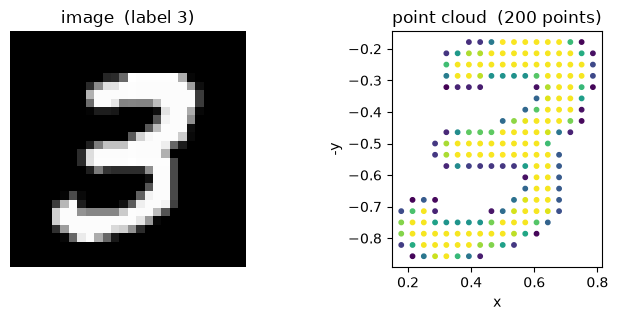

In [6]:
# Visualize one example: image  <->  point cloud
ds_vis, name = load_image_dataset("../data", train=True)
print("Loaded:", name)
img, label = ds_vis[7]
pts = image_to_pointcloud(img)

fig, ax = plt.subplots(1, 2, figsize=(7, 3.3))
ax[0].imshow(img[0], cmap="gray"); ax[0].set_title(f"image  (label {label})"); ax[0].axis("off")
ax[1].scatter(pts[:, 0], -pts[:, 1], c=pts[:, 2], cmap="viridis", s=10)
ax[1].set_title(f"point cloud  ({pts.shape[0]} points)")
ax[1].set_aspect("equal"); ax[1].set_xlabel("x"); ax[1].set_ylabel("-y")
plt.tight_layout(); plt.show()

In [7]:
# ========================================================================================
# DATA PREPARATION & LOADING
# ========================================================================================

# Instantiate the custom PointCloudImages dataset for the training set.
# This dynamically reads the 28x28 MNIST images and converts them into (X, Y, Intensity) 3D coordinates.
full_train = PointCloudImages("../data", train=True)

# Instantiate the same dataset, but for the held-out testing set.
full_test  = PointCloudImages("../data", train=False)

# To ensure the training runs in roughly a minute on a standard laptop, we don't use the full 60,000 images.
# torch.utils.data.Subset creates a smaller virtual dataset using only the first 20,000 indices.
train_ds = Subset(full_train, range(20000))

# Similarly, we restrict the test set to the first 5,000 images to speed up evaluation.
test_ds  = Subset(full_test,  range(5000))

# The DataLoader manages the batching and delivery of data.
# batch_size=128: Grabs 128 point clouds at a time.
# shuffle=True: Randomizes the draw order to prevent the model from memorizing sequence patterns.
# collate_fn=pad_collate: Crucially, this injects our custom padding function to ensure all 128 point clouds
# in the batch are padded with zeros to match the size of the largest cloud in that specific batch,
# yielding rectangular tensors of shape (128, N_max, 3).
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True,  collate_fn=pad_collate)

# The test loader does the same for testing.
# shuffle=False: We don't need to randomize during testing since no learning occurs.
# batch_size=256: Because testing requires no memory for mathematical gradients, we can process larger chunks at once.
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False, collate_fn=pad_collate)


# ========================================================================================
# MODEL INITIALIZATION & OPTIMIZER
# ========================================================================================

# Initialize the DeepSets model we defined earlier.
# in_features=3: We pass in X, Y, and Intensity coordinates.
# n_classes=10: We are classifying digits 0 through 9.
# pool="sum": We use mathematical addition to aggregate the points, satisfying the invariant sum
# in the Deep Sets theorem: f(X) = ρ(Σ φ(x_i)).
# .to(device): Pushes the model's internal weights to the active hardware accelerator (GPU or CPU).
model = DeepSetsClassifier(in_features=3, n_classes=10, pool="sum").to(device)

# Initialize the Adam optimizer.
# Adam uses moving averages of the gradients to adaptively tune the learning rate for every individual parameter.
# lr=1e-3: The base learning rate step size (0.001).
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
# Q: What are the risks of using an LRR?
# Q: How would one implement such a function by hand or through torch?

# ========================================================================================
# DUAL-PURPOSE EPOCH FUNCTION (TRAINING & EVALUATION)
# ========================================================================================

# This function is cleverly designed to handle both learning (training) and grading (testing).
def run_epoch(loader, train):

    # model.train(train) sets the internal state of the model.
    # If train=True, it activates behaviors like Dropout (randomly turning off neurons) and Batch Normalization tracking.
    # If train=False, it freezes these behaviors to ensure deterministic, consistent predictions during testing.
    model.train(train)

    # Initialize three tracking counters at 0.
    loss_sum = correct = total = 0

    # torch.set_grad_enabled dynamically turns the auto-differentiation math engine on or off.
    # If train=True, it builds the computation graph required for back-propagation.
    # If train=False, it completely disables the graph, drastically reducing memory consumption and speeding up processing.
    torch.set_grad_enabled(train)

    # Iterate through the batches provided by the DataLoader.
    for x, mask, y in loader:

        # Transfer the point cloud tensor (x), the 0/1 validity mask (mask), and the labels (y) to the GPU/CPU.
        x, mask, y = x.to(device), mask.to(device), y.to(device)

        # Forward Pass: Send the coordinates and mask through the DeepSets architecture.
        # Output 'logits' are raw, unconstrained real numbers corresponding to the 10 digit classes.
        logits = model(x, mask)

        # Compute the Cross-Entropy Loss.
        # This mathematically combines two steps:
        # 1. Softmax: Converts the raw logits into a proper probability distribution summing to 1.
        #    $p_c = \frac{\exp(logit_c)}{\sum \exp(logit_j)}$
        # 2. Negative Log-Likelihood: Penalizes the model based on the log-probability assigned to the TRUE class 'y'.
        #    $Loss = -\log(p_y)$
        loss = F.cross_entropy(logits, y)

        # If we are in the training phase, we execute the backpropagation and weight updates.
        if train:
            # 1. opt.zero_grad(): Wipes away the partial derivatives (gradients) accumulated from the previous batch.
            # 2. loss.backward(): Applies the Chain Rule of Calculus backward through the network to compute
            #    the gradient of the loss with respect to every weight (∂Loss / ∂Weight).
            # 3. opt.step(): The Adam optimizer physically updates the weights in the direction that minimizes the loss.
            opt.zero_grad(); loss.backward(); opt.step()

        # loss.item() gives the average loss for this batch. Multiplying by y.size(0) (the batch size)
        # unwinds the average so we can keep a running sum of the absolute total error.
        loss_sum += loss.item() * y.size(0)

        # Calculate Accuracy for the batch.
        # 1. logits.argmax(-1): Looks across the 10 class predictions (the last dimension, dim=-1) and grabs the index of the highest score.
        # 2. ( ... == y): Creates a boolean tensor comparing the guesses to the true labels (True if correct, False if wrong).
        # 3. .sum().item(): Adds up all the Trues (1s) to get the raw count of correct guesses as a standard Python integer.
        correct  += (logits.argmax(-1) == y).sum().item()

        # Add the number of items in this batch to our running total of samples processed.
        total    += y.size(0)

    # Before exiting, safely turn the gradient tracking engine back on globally to prevent downstream bugs.
    torch.set_grad_enabled(True)

    # Return the average loss across all samples, and the overall accuracy percentage.
    return loss_sum / total, correct / total


# ========================================================================================
# MAIN EXECUTION LOOP
# ========================================================================================

# Loop exactly 5 times (epochs). In one epoch, the model sees every single training example exactly once.
for epoch in range(5):

    # Execute the training phase: the model learns from 'train_loader', updating its weights.
    tr_loss, tr_acc = run_epoch(train_loader, True)

    # Execute the evaluation phase: the model is frozen and graded on 'test_loader'.
    te_loss, te_acc = run_epoch(test_loader,  False)

    # Print the progress for the current epoch, formatting the accuracy floats to 3 decimal places.
    print(f"epoch {epoch+1}:  train acc {tr_acc:.3f}  |  test acc {te_acc:.3f}")

epoch 1:  train acc 0.118  |  test acc 0.138
epoch 2:  train acc 0.330  |  test acc 0.484
epoch 3:  train acc 0.565  |  test acc 0.584
epoch 4:  train acc 0.650  |  test acc 0.608
epoch 5:  train acc 0.676  |  test acc 0.674


### The key check: is the model *really* permutation-invariant?

We now take a batch, run it, then **shuffle the points within every set** (and the mask the same way) and
run it again. For a true DeepSet the two outputs are identical to floating-point precision — the symmetry
holds *by construction*, not because we trained for it.

In [8]:
# ========================================================================================
# NUMERICAL VERIFICATION OF PERMUTATION INVARIANCE
# ========================================================================================

# Lock the model into evaluation mode.
# This explicitly disables stochastic (random) operations like Dropout.
# It guarantees the model behaves deterministically. Without this, two identical inputs
# might yield slightly different outputs due to random neuron dropping, ruining our mathematical proof.
model.eval()

# Extract exactly one batch of data from the testing DataLoader.
# iter() converts the loader into a Python iterator, and next() grabs the very first payload.
# 'x' is the tensor of coordinates: (Batch, N_points, Features).
# 'mask' is the 0/1 validity tensor: (Batch, N_points).
# 'y' is the true label tensor (which we don't need for this specific test).
x, mask, y = next(iter(test_loader))

# Push the point coordinates and the mask to the active hardware accelerator (CPU/GPU).
x, mask = x.to(device), mask.to(device)

# Temporarily disable PyTorch's autograd engine (the gradient tracker).
# Because we are only verifying the forward math and not training, this prevents PyTorch
# from building a memory-heavy computational graph in the background.
with torch.no_grad():
    # Test 1 (Baseline): Pass the raw, unshuffled point clouds and masks through the DeepSet.
    # out1 contains the final predicted logits for this batch. Shape: (Batch, 10).
    out1 = model(x, mask)

    # Generate a random permutation sequence for the particle dimension.
    # x.shape[1] gives us 'N_points' (the max sequence length in this specific batch).
    # torch.randperm creates a 1D tensor of integers from 0 to N_points-1 in a completely randomized order.
    perm = torch.randperm(x.shape[1])  # one shuffle of the point axis

    # Test 2 (Permuted): Pass the SHUFFLED point clouds and SHUFFLED masks through the model.
    # Advanced Indexing Breakdown:
    #   x[:, perm, :] -> Keeps all batches (dim 0), shuffles the particles according to 'perm' (dim 1),
    #                    and keeps all 3 spatial features perfectly attached to their respective particles (dim 2).
    #   mask[:, perm] -> Shuffles the 0/1 validity mask using the EXACT same sequence, ensuring
    #                    that the "fake" padding zeros stay correctly mapped to the padded particles.
    out2 = model(x[:, perm, :], mask[:, perm])

# The Mathematical Proof (L_infinity norm):
# If the Deep Sets theorem holds, the invariant function mathematically guarantees that f(X) = f(PX),
# where P is a permutation matrix.
# 1. (out1 - out2) subtracts the two logit tensors element-wise.
# 2. .abs() converts all differences into positive numbers.
# 3. .max() scans the entire batch and all 10 class predictions to find the single largest discrepancy.
# 4. .item() extracts that value from the PyTorch tensor into a standard Python float for printing.
print(
    "max |f(x) - f(shuffled x)| =",
    (out1 - out2).abs().max().item(),
    "  (~0  =>  permutation invariant by construction)",
)

max |f(x) - f(shuffled x)| = 3.814697265625e-06   (~0  =>  permutation invariant by construction)


## 6 · The real thing: tagging jets with a Particle Flow Network

Now jets. We read the **JetClass** example file (100k jets) and build a binary task:
**top quark jets (signal)** vs **QCD light-quark/gluon jets (background)** — the standard jet-tagging benchmark.

**Per-particle features.** From each particle's 4-momentum $(p_x,p_y,p_z,E)$ and its position relative to the
jet axis $(\Delta\eta,\Delta\phi)$ we build a small, physically sensible feature vector:

| feature | meaning |
|---|---|
| $\Delta\eta,\ \Delta\phi$ | angular position w.r.t. the jet axis |
| $\log p_T,\ \log E$ | momentum / energy on a log scale (wide dynamic range) |
| $\log(p_T/\sum p_T),\ \log(E/\sum E)$ | momentum / energy *fraction* within the jet |
| $\Delta R=\sqrt{\Delta\eta^2+\Delta\phi^2}$ | distance to the jet axis |

The **PFN** is exactly the DeepSet from §4: embed each particle with $\Phi$, **sum** over particles, classify
with $F$. We reuse `DeepSetsClassifier` unchanged — only `in_features` and `n_classes` differ.

In [9]:
import os
import uproot
import awkward as ak

# The notebook searches a few standard locations for the JetClass example file.
CANDIDATE_PATHS = [
    "../data/JetClass_example_100k.root",
    "/Users/sanmay/Documents/ML_SCHOOLS/MLSCHOOL_2023_ICTS/Main_School/JetDataset/JetClass_example_100k.root",
    "./JetClass_example_100k.root",
]
root_path = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), None)
if root_path is None:
    raise FileNotFoundError(
        "JetClass example file not found. Download 'JetClass_example_100k.root' from "
        "https://hqu.web.cern.ch/datasets/JetClass/example/ and place it in ../data/.\n"
        f"Searched: {CANDIDATE_PATHS}")
print("Using:", root_path)

Using: ../data/JetClass_example_100k.root


In [10]:
# ========================================================================================
# CONSTANTS & DATA LOADING
# ========================================================================================

# MAX_PART: Neural networks require fixed-size inputs. We enforce a hard limit of 128 particles per jet.
# If a jet has 150 particles, we chop off the lowest energy ones. If it has 50, we pad with 78 zeros.
MAX_PART  = 128

# N_PER_CLS: To prevent the AI from defaulting to the most common answer, we force a balanced dataset
# of exactly 8,000 jets per category (16,000 total).
N_PER_CLS = 8000

# uproot is a Python library that reads .root files (the standard data format at CERN/Fermilab)
# without needing to install the massive C++ ROOT framework.
tree = uproot.open(root_path)["tree"]

# Extract only the specific branches (columns) we need into memory using Awkward Array (ak).
# Awkward Arrays are crucial here because physics data is "jagged" (every collision produces
# a different, unpredictable number of particles).
br = tree.arrays(["part_px", "part_py", "part_pz", "part_energy", "part_deta", "part_dphi",
                  "label_QCD", "label_Tbqq", "label_Tbl"])


# ========================================================================================
# BALANCED SUBSET SELECTION
# ========================================================================================

# Convert the awkward arrays of labels into standard numpy boolean masks (True/False).
# label_QCD is the background noise (label 0).
is_qcd = ak.to_numpy(br["label_QCD"]).astype(bool)

# Top quarks decay in different ways (Tbqq or Tbl). The bitwise OR operator (|)
# combines them so if either is True, it qualifies as a Top jet (label 1).
is_top = ak.to_numpy(br["label_Tbqq"]).astype(bool) | ak.to_numpy(br["label_Tbl"]).astype(bool)

# np.where(is_qcd)[0] finds the exact row indices where the QCD mask is True.
# [:N_PER_CLS] slices that list to grab exactly the first 8,000 indices.
idx_qcd = np.where(is_qcd)[0][:N_PER_CLS]
idx_top = np.where(is_top)[0][:N_PER_CLS]

# np.concatenate glues the two lists of indices together into one master selection list of 16,000 jets.
sel = np.concatenate([idx_qcd, idx_top])

# Create the master answer key (y-values) for the AI.
# Create 8,000 zeros, create 8,000 ones, glue them together, and force them to be 64-bit integers.
labels = np.concatenate([np.zeros(len(idx_qcd)), np.ones(len(idx_top))]).astype(np.int64)
print(f"selected {len(idx_qcd)} QCD + {len(idx_top)} top jets")

# Apply our master selection list to the raw physics arrays.
# This filters the dataset down to our chosen 16,000 jets, but the data is STILL jagged
# (e.g., px is a list of 16,000 lists, all of varying lengths).
px, py, pz, e = br["part_px"][sel], br["part_py"][sel], br["part_pz"][sel], br["part_energy"][sel]
deta, dphi    = br["part_deta"][sel], br["part_dphi"][sel]


# ========================================================================================
# VECTORIZED FEATURE ENGINEERING
# ========================================================================================

# Calculate Transverse Momentum (pT): The momentum perpendicular to the beamline.
# Math: pT = sqrt(px^2 + py^2)
pt    = np.sqrt(px**2 + py**2)

# Calculate Delta R: The spatial distance between particles in the detector cylinder.
# Math: dR = sqrt(deta^2 + dphi^2)
dR    = np.sqrt(deta**2 + dphi**2)

# Calculate the total pT and total Energy for each individual jet.
# ak.sum(..., axis=1) collapses the particle dimension, leaving one scalar total per jet.
sumpt = ak.sum(pt, axis=1)
sume  = ak.sum(e,  axis=1)

# Apply natural logarithms to highly skewed values to make the neural network train faster.
# "+ 1e-8" is a critical safety mechanism. Log(0) equals negative infinity, which instantly
# crashes neural networks (NaN loss). Adding 0.00000001 prevents the crash without altering the math.
logpt    = np.log(pt + 1e-8)
loge     = np.log(e  + 1e-8)

# Calculate logarithmic relative fractions (what percentage of the jet's total energy does this particle hold?)
logptrel = np.log(pt / sumpt + 1e-8)
logerel  = np.log(e  / sume  + 1e-8)

# Group the engineered features into a list so we can process them efficiently in a loop.
FEATURE_NAMES = ["deta", "dphi", "log_pt", "log_e", "log_pt_rel", "log_e_rel", "dR"]
feat_list     = [deta,    dphi,   logpt,    loge,    logptrel,     logerel,     dR]


# ========================================================================================
# JAGGED TO DENSE TENSOR CONVERSION
# ========================================================================================

def pad_feature(f):
    """jagged (Njet, var) -> regular numpy (Njet, MAX_PART), truncating/padding with 0."""
    # 1. ak.pad_none(..., MAX_PART, clip=True):
    #    If a jet has < 128 particles, it adds empty 'None' slots.
    #    If it has > 128 particles, clip=True aggressively truncates it back to 128.
    # 2. ak.fill_none(..., 0.0): Replaces all the empty 'None' slots with physical 0.0 values.
    # 3. ak.to_numpy(): Safely converts the now-rectangular Awkward array into a standard, fast Numpy array.
    return ak.to_numpy(ak.fill_none(ak.pad_none(f, MAX_PART, clip=True), 0.0))

# Execute the padding function on all 7 features via list comprehension.
# np.stack(..., axis=-1) glues the 7 individual 2D grids (Jets x Particles) together along the depth axis.
# The resulting tensor X has the shape: (16000 Jets, 128 Particles, 7 Features).
X = np.stack([pad_feature(f) for f in feat_list], axis=-1).astype(np.float32)


# ========================================================================================
# MASK GENERATION & EFN PREP
# ========================================================================================

# ak.num(...) counts how many actual, real particles are in each jet.
# np.minimum(..., MAX_PART) ensures that if a jet originally had 150 particles, we cap the "real" count at 128.
nparts = np.minimum(ak.to_numpy(ak.num(pt, axis=1)), MAX_PART)

# Advanced numpy broadcasting to create the Boolean mask without a 'for' loop:
# 1. np.arange(MAX_PART)[None, :] creates a row vector: [0, 1, 2, ..., 127]
# 2. nparts[:, None] creates a column vector of the real particle counts.
# 3. The '<' operator compares them. If the index is less than the count, it yields True (1.0).
#    If the index exceeds the count (meaning it's padded space), it yields False (0.0).
mask = (np.arange(MAX_PART)[None, :] < nparts[:, None]).astype(np.float32)

# Energy Flow Networks (EFNs) require un-normalized, raw input geometry.
# We explicitly pad and extract just the spatial angles (eta, phi) for this architecture.
angles = np.stack([pad_feature(deta), pad_feature(dphi)], axis=-1).astype(np.float32)

# EFNs use the linear fraction z = pT / sum(pT) rather than the logarithmic fraction.
# We calculate z, pad it, and enforce 32-bit floats for GPU efficiency.
zfrac  = pad_feature(pt / sumpt).astype(np.float32)

# Final reality check output to ensure dimensions align perfectly before feeding to the neural network.
print("X:", X.shape, " mask:", mask.shape, " angles:", angles.shape, " z:", zfrac.shape)

selected 8000 QCD + 8000 top jets
X: (16000, 128, 7)  mask: (16000, 128)  angles: (16000, 128, 2)  z: (16000, 128)


In [11]:
# ========================================================================================
# TENSOR CONVERSION & SYNCHRONIZED SHUFFLING
# ========================================================================================

# torch.from_numpy is a highly efficient operation that creates a PyTorch tensor
# that shares the exact same underlying memory buffer as the original Numpy array.
# This completely avoids copying the massive data structures in RAM.
Xt, Mt, Yt = torch.from_numpy(X), torch.from_numpy(mask), torch.from_numpy(labels)
AnglesT, Zt = torch.from_numpy(angles), torch.from_numpy(zfrac)

# torch.Generator().manual_seed(0) locks the random number generator to a specific starting point.
# This ensures "reproducibility"—every time you run this script, it will shuffle the data
# in the exact same random order, which is critical for debugging and comparing different models.
g = torch.Generator().manual_seed(0)

# randperm creates a 1D tensor containing the integers from 0 to len(Yt)-1 (which is 15,999)
# arranged in a completely randomized sequence.
perm = torch.randperm(len(Yt), generator=g)

# By applying this exact same permutation index array to every single tensor,
# we shuffle the entire dataset (features, masks, labels, angles) simultaneously and synchronously.
# Jet #5's features stay perfectly locked to Jet #5's label and mask, just moved to a new row.
Xt, Mt, Yt, AnglesT, Zt = Xt[perm], Mt[perm], Yt[perm], AnglesT[perm], Zt[perm]


# ========================================================================================
# DATA SPLITTING (TRAIN / VALIDATION / TEST)
# ========================================================================================

# Extract the total number of jets (16,000).
n = len(Yt)

# Calculate the strict cutoff integer indices for the splits:
# n_tr = 70% of 16,000 (11,200 jets for training the network).
# n_va = 15% of 16,000 (2,400 jets for validating and tuning hyperparameters).
# The remaining 15% (2,400 jets) implicitly becomes the completely untouched test set.
n_tr, n_va = int(0.70 * n), int(0.15 * n)

# Python 'slice' objects are stored in a dictionary.
# They act as reusable variables representing the start and stop indices for our three groups.
# slice(0, 11200) for train, slice(11200, 13600) for val, slice(13600, 16000) for test.
sl = {
    "train": slice(0, n_tr),
    "val": slice(n_tr, n_tr + n_va),
    "test": slice(n_tr + n_va, n),
}


# ========================================================================================
# Z-SCORE STANDARDIZATION (PREVENTING DATA LEAKAGE)
# ========================================================================================

# Neural networks learn best when all input features have a mean of 0 and a standard deviation of 1.
# CRITICAL ML RULE: You can only calculate these statistics using the TRAINING data.
# If you use the whole dataset, information about the test set "leaks" into the training process.

# 1. Xt[sl["train"]] extracts only the 11,200 training jets. Shape: (11200, 128, 7)
# 2. Mt[sl["train"]].bool() extracts their corresponding 0/1 masks and converts them to True/False.
# 3. Advanced PyTorch Indexing: Passing a 2D boolean mask into a 3D tensor extracts ONLY the
#    data points where the mask is True, instantly discarding all the fake padding zeros.
# 4. This flattens the result into a 2D matrix called 'flat' containing ONLY the actual, physical
#    particles from the training set. Shape: (total_real_particles, 7)
flat = Xt[sl["train"]][Mt[sl["train"]].bool()]

# Calculate the statistical Mean (average) and Standard Deviation (spread) across axis 0
# (which means we calculate one mean and one std for each of the 7 features).
# .clamp(min=1e-6) is a safety net: if a feature has zero variance (all values are identical),
# its std is 0. Clamping it to a microscopic number prevents a fatal divide-by-zero crash.
feat_mean, feat_std = flat.mean(0), flat.std(0).clamp(min=1e-6)

# Apply the Standardization formula: Z = (X - Mean) / Std
# Because of PyTorch broadcasting, this subtracts the 7-element mean vector from all 7 features
# across all 16,000 jets (Train, Val, and Test) and divides by the std vector.
Xt = (Xt - feat_mean) / feat_std

# NOTE: The dummy padding slots used to be exactly 0.0.
# Because of the math above, (0.0 - mean) / std is no longer 0.0; it becomes a random garbage number.
# This is completely fine because our custom `masked_sum` and `masked_mean` functions inside
# the Deep Sets architecture will physically multiply these garbage slots by 0 (the mask)
# before adding them up, completely neutralizing them.

# Final sanity check: We re-extract the real training particles from the NOW standardized tensor
# and calculate their mean. It should print out a vector of seven numbers that are extremely close to 0.0.
print(
    "standardized feature means ~0:",
    Xt[sl["train"]][Mt[sl["train"]].bool()].mean(0).numpy().round(2),
)


standardized feature means ~0: [ 0. -0.  0.  0.  0.  0.  0.]


In [12]:
# ========================================================================================
# CUSTOM MULTI-TENSOR DATASET CLASS
# ========================================================================================

# We define a highly flexible, custom PyTorch Dataset class called 'TensorSet'.
# Standard PyTorch datasets (like TensorDataset) usually assume a fixed number of inputs (like just X and Y).
# Because our physics models require different numbers of inputs (PFNs need 3, EFNs need 4),
# this custom class dynamically handles any arbitrary tuple of tensors.
class TensorSet(Dataset):
    # The constructor accepts 'tensors', which is a tuple containing our data matrices
    # (e.g., (Features, Masks, Labels) or (Angles, Z_Fractions, Masks, Labels)).
    def __init__(self, tensors):
        self.tensors = tensors

    # PyTorch DataLoaders require a __len__ function to know exactly how many batches exist in an epoch.
    # We look at the very first tensor in our tuple (e.g., the Features tensor), and return
    # its 0th dimension (the total number of jets, which is 11,200 for the training split).
    def __len__(self):
        return len(self.tensors[0])

    # The __getitem__ function dictates exactly what is returned when the DataLoader asks for the i-th item.
    # It uses a Python generator expression: for every tensor 't' in our tuple, grab the i-th row (t[i]).
    # It bundles these parallel rows together and returns them as a single cohesive tuple for that specific jet.
    def __getitem__(self, i):
        return tuple(t[i] for t in self.tensors)


# ========================================================================================
# DATALOADER DICTIONARY COMPREHENSIONS (PFN vs EFN)
# ========================================================================================

# Particle Flow Networks (PFNs) process the fully engineered, standardized physics features.
# They require three things per jet: X (standardized features), mask (0/1 validity map), and y (the true label).
# We use a Python dictionary comprehension {key: value for key, value in dict.items()} to instantly build
# three separate DataLoaders ("train", "val", "test") in a single line of code.
pfn_loaders = {
    # For each split 'k' (like "train") and its corresponding index slice 's' (like slice(0, 11200)):
    # 1. We slice the master tensors (Xt[s], Mt[s], Yt[s]) to isolate just that specific dataset split.
    # 2. We wrap those sliced tensors in our custom TensorSet.
    # 3. We wrap the TensorSet in a DataLoader, telling it to serve the data in chunks of 256 jets.
    # 4. shuffle=(k == "train") is a brilliant logical trick: if k is "train", this evaluates to True,
    #    so the training data gets shuffled. If k is "val" or "test", it evaluates to False, saving compute time.
    k: DataLoader(
        TensorSet((Xt[s], Mt[s], Yt[s])), batch_size=256, shuffle=(k == "train")
    )
    for k, s in sl.items()
}

# Energy Flow Networks (EFNs) are a specialized architecture that operate on raw geometric angles and energy fractions,
# strictly enforcing the physical principle of Infrared and Collinear (IRC) safety.
# Because of this architectural difference, they consume four inputs: angles (eta, phi), z (energy fraction), mask, and y.
# We run the exact same dictionary comprehension logic, but feed the AnglesT and Zt tensors instead of Xt.
efn_loaders = {
    k: DataLoader(
        TensorSet((AnglesT[s], Zt[s], Mt[s], Yt[s])),
        batch_size=256,
        shuffle=(k == "train"),
    )
    for k, s in sl.items()
}


In [13]:
# Import Scikit-Learn functions for evaluating binary classification models.
# ROC AUC is the standard metric for measuring a model's ability to distinguish between two classes.
from sklearn.metrics import roc_auc_score, roc_curve


# ========================================================================================
# UNIVERSAL EVALUATION FUNCTION (TESTING / VALIDATION)
# ========================================================================================

# The @torch.no_grad() decorator automatically applies 'with torch.no_grad():' to the entire function.
# It completely disables the computation graph (gradient tracking), drastically reducing memory usage
# and speeding up inference since we are only testing, not learning.
@torch.no_grad()
def evaluate(model, loader, kind="pfn"):

    # Lock the model into evaluation mode (disables Dropout and freezes Batch Normalization).
    model.eval()

    # Initialize lists to store the true labels (ys) and predicted probabilities (ps) for the entire dataset.
    # Initialize loss_sum to track the total mathematical error, and ntot for the total number of jets processed.
    ys, ps, loss_sum, ntot = [], [], 0.0, 0

    # Iterate through every batch in the provided DataLoader.
    for batch in loader:

        # A list comprehension to move every tensor in the current batch (X, mask, y, etc.)
        # from the CPU RAM to the active accelerator device (GPU).
        batch = [b.to(device) for b in batch]

        # Dynamic routing based on the model architecture type:
        if kind == "pfn":
            # PFNs take 3 inputs. Unpack them and run the forward pass to get raw prediction logits.
            x, m, y = batch; logits = model(x, m)
        else:
            # EFNs take 4 inputs (Angles, Z-fractions, mask, labels). Unpack and run forward pass.
            a, z, m, y = batch; logits = model(a, z, m)

        # 1. Calculate Cross-Entropy Loss for the batch.
        # 2. reduction="sum" overrides the default (which averages the loss). This calculates the
        #    ABSOLUTE total error for the batch so we can perfectly average it later across the whole dataset.
        # 3. .item() extracts the total from the PyTorch graph into a standard Python float.
        loss_sum += F.cross_entropy(logits, y, reduction="sum").item()

        # Add the number of jets in this batch to our running total.
        ntot += y.size(0)

        # Store the True Labels. .cpu() pulls the tensor off the GPU back to standard RAM.
        ys.append(y.cpu())

        # Store the Predicted Probabilities for the SIGNAL class (Top Quark / Label 1).
        # 1. F.softmax(logits, -1) converts the raw [-inf, inf] logits into [0.0, 1.0] probabilities summing to 1.
        # 2. [:, 1] slices the 2D tensor (Batch, 2_classes), extracting only the column for class index 1 (the Top jet probability).
        # 3. .cpu() moves it back to standard RAM.
        ps.append(F.softmax(logits, -1)[:, 1].cpu())

    # After the loop, torch.cat glues the list of batch tensors into one massive, continuous 1D tensor for the whole dataset.
    # .numpy() safely converts these PyTorch tensors into standard Scikit-Learn compatible arrays.
    y = torch.cat(ys).numpy()
    p = torch.cat(ps).numpy()

    # Calculate and return a dictionary of evaluation metrics:
    # 1. "loss": The true average mathematical error (Total Error / Total Jets).
    # 2. "acc": (p > 0.5) converts probabilities into hard 0 or 1 predictions. We compare to 'y' and take the mean (.mean()) for accuracy.
    # 3. "auc": The Area Under the Receiver Operating Characteristic (ROC) Curve. 1.0 is perfect, 0.5 is random guessing.
    # 4. "y" & "p": We return the raw arrays so we can plot graphs with them later.
    return {"loss": loss_sum / ntot, "acc": ((p > 0.5).astype(int) == y).mean(),
            "auc": roc_auc_score(y, p), "y": y, "p": p}


# ========================================================================================
# UNIVERSAL TRAINING LOOP
# ========================================================================================

# A streamlined training function that handles both PFN and EFN architectures.
def train_model(model, loaders, kind="pfn", epochs=8, lr=1e-3):

    # Initialize the Adam optimizer, linking it to the model's physical weights (parameters).
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    # Loop over the dataset 'epochs' times.
    for ep in range(epochs):

        # Set the model to training mode (enabling gradients and dropout).
        model.train()

        # Iterate over the designated "train" split DataLoader.
        for batch in loaders["train"]:

            # Push data to GPU.
            batch = [b.to(device) for b in batch]

            # Dynamic routing for forward pass (just like in the evaluate function).
            if kind == "pfn":
                x, m, y = batch; logits = model(x, m)
            else:
                a, z, m, y = batch; logits = model(a, z, m)

            # Compute the batch loss (using default reduction="mean" here for stable gradient math).
            loss = F.cross_entropy(logits, y)

            # The holy trinity of PyTorch training:
            # 1. Wipe the old gradients. 2. Calculate the new gradients. 3. Physically shift the weights.
            opt.zero_grad(); loss.backward(); opt.step()

        # At the very end of the training epoch, run our custom evaluate() function on the unseen "val" dataset.
        va = evaluate(model, loaders["val"], kind)

        # Print the validation results to the console so we can monitor if the AI is actually learning or just memorizing.
        print(f"epoch {ep+1:2d}:  val loss {va['loss']:.3f}  acc {va['acc']:.3f}  AUC {va['auc']:.4f}")

    # Return the fully trained model.
    return model


# ========================================================================================
# HIGH ENERGY PHYSICS (HEP) CUSTOM METRIC
# ========================================================================================

# In physics, standard Accuracy is usually useless because background events (noise) vastly outnumber signal events.
# Physicists use "Background Rejection at X% Signal Efficiency".
# This tells us: "If we set our AI's confidence threshold so that we successfully catch 50% of the real Top quarks,
# how much of the QCD background noise do we successfully reject?"
def background_rejection(y, p, target_eff=0.5):
    """1 / eps_B at fixed signal efficiency eps_S = target_eff (the standard HEP tagging metric)."""

    # roc_curve sweeps through every possible confidence threshold (from 0.0 to 1.0) and calculates:
    # 1. fpr (False Positive Rate / Background Efficiency / eps_b): % of noise accidentally labeled as signal.
    # 2. tpr (True Positive Rate / Signal Efficiency / eps_s): % of true signal correctly labeled as signal.
    fpr, tpr, _ = roc_curve(y, p)

    # We want to know the exact False Positive Rate (fpr) at our strictly chosen True Positive Rate (target_eff=0.5).
    # Because our calculated 'tpr' array is a series of discrete points, np.interp draws straight mathematical lines
    # between those points (linear interpolation) to estimate the exact 'fpr' value at precisely 0.5 'tpr'.
    eps_b = np.interp(target_eff, tpr, fpr)

    # Background rejection is defined as the mathematical inverse of the False Positive Rate (1 / fpr).
    # If our FPR is 0.01 (we let 1% of noise through), our rejection factor is 100.
    # max(eps_b, 1e-12) is a safety net. If our model is perfectly flawless and eps_b is exactly 0.0,
    # it forces it to a microscopic number to prevent a divide-by-zero fatal crash.
    return 1.0 / max(eps_b, 1e-12)

In [14]:
# Train the PFN
pfn = DeepSetsClassifier(in_features=len(FEATURE_NAMES),
                         phi_hidden=(64, 128, 128), latent=128,
                         f_hidden=(128, 64), n_classes=2, pool="sum").to(device)
train_model(pfn, pfn_loaders, kind="pfn", epochs=8)

epoch  1:  val loss 0.524  acc 0.760  AUC 0.8567
epoch  2:  val loss 0.376  acc 0.850  AUC 0.9159
epoch  3:  val loss 0.307  acc 0.874  AUC 0.9426
epoch  4:  val loss 0.235  acc 0.907  AUC 0.9665
epoch  5:  val loss 0.220  acc 0.908  AUC 0.9707
epoch  6:  val loss 0.212  acc 0.918  AUC 0.9732
epoch  7:  val loss 0.191  acc 0.922  AUC 0.9775
epoch  8:  val loss 0.188  acc 0.925  AUC 0.9789


DeepSetsClassifier(
  (phi): Sequential(
    (0): Linear(in_features=7, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=128, bias=True)
  )
  (f): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)

PFN test  AUC = 0.9787   acc = 0.9308
   background rejection 1/eps_B @ eps_S=0.3:    1210.0
   background rejection 1/eps_B @ eps_S=0.5:     302.5
   background rejection 1/eps_B @ eps_S=0.7:     172.9


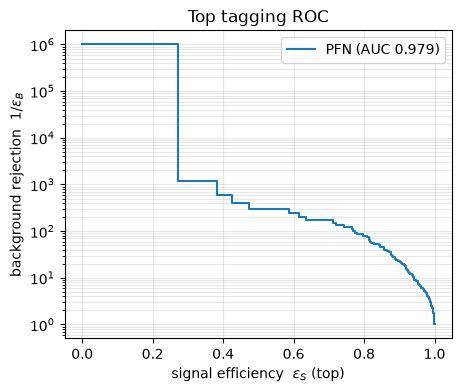

In [15]:
# Evaluate on the held-out test set: AUC + background rejection, and the ROC curve.
res_pfn = evaluate(pfn, pfn_loaders["test"], kind="pfn")
print(f"PFN test  AUC = {res_pfn['auc']:.4f}   acc = {res_pfn['acc']:.4f}")
for eff in (0.3, 0.5, 0.7):
    print(f"   background rejection 1/eps_B @ eps_S={eff}:  {background_rejection(res_pfn['y'], res_pfn['p'], eff):8.1f}")

fpr, tpr, _ = roc_curve(res_pfn["y"], res_pfn["p"])
plt.figure(figsize=(5, 4))
plt.plot(tpr, 1.0 / np.clip(fpr, 1e-6, 1), label=f"PFN (AUC {res_pfn['auc']:.3f})")
plt.yscale("log"); plt.xlabel("signal efficiency  $\\epsilon_S$ (top)")
plt.ylabel("background rejection  $1/\\epsilon_B$")
plt.grid(True, which="both", alpha=0.3); plt.legend(); plt.title("Top tagging ROC"); plt.show()

## 7 · Energy Flow Networks and infrared-&-collinear (IRC) safety

The PFN is powerful but it is *not* guaranteed to respect a deep property of QCD. Detectors and parton
showers introduce two kinds of "harmless" changes that **must not** change a physical observable:

- **Collinear splitting:** one particle splits into two moving in the *same direction*, sharing its momentum.
- **Infrared (soft) emission:** an extra particle appears carrying *vanishing* energy.

An observable that is invariant under both is called **IRC-safe**. The **Energy Flow Network** builds this in:
$$ \text{EFN}(\{x_i\}) \;=\; F\!\Big( \sum_i z_i\, \Phi(\hat{n}_i) \Big),\qquad z_i=\frac{p_{T,i}}{\sum_j p_{T,j}} , $$
where $\Phi$ sees **only the angles** $\hat n_i=(\Delta\eta,\Delta\phi)$ and the per-particle weight $z_i$ is the
**energy fraction**. Why this is IRC-safe:
- *Collinear:* splitting a particle into two at the same angle splits $z$ into $z/2+z/2$ at the same $\Phi$, so
  $\sum_i z_i\Phi(\hat n_i)$ is **unchanged**.
- *Soft:* a particle with $p_T\to 0$ has $z\to 0$, so it contributes **nothing**.

We train an EFN and then *demonstrate* both guarantees numerically.

In [16]:
# ========================================================================================
# ENERGY FLOW NETWORK (EFN) ARCHITECTURE
# ========================================================================================

# Define the Energy Flow Network (EFN) architecture.
# Unlike standard Deep Sets, EFNs are explicitly designed to be "IRC-safe"
# (Infrared and Collinear safe). This is a fundamental law in quantum physics dictating that:
# 1. Infrared safety: Adding a particle with zero energy should not change the measurement.
# 2. Collinear safety: Splitting one particle into two identical particles moving in the
#    exact same direction should not change the measurement.
class EFN(nn.Module):
    """Energy Flow Network (IRC-safe):  F( sum_i z_i * Phi(angles_i) ).
    angles: (B, N, 2) = (deta, dphi)   z: (B, N) energy fractions   mask: (B, N)
    """

    # Initialize the two core neural networks (MLPs).
    # n_angle=2: The input features are purely geometric (just eta and phi). Energy is EXCLUDED here.
    # phi_hidden, latent: Defines the architecture for the spatial embedding function.
    # f_hidden, n_classes: Defines the final classification decoder.
    def __init__(
        self,
        n_angle=2,
        phi_hidden=(64, 128, 128),
        latent=128,
        f_hidden=(128, 64),
        n_classes=2,
    ):
        super().__init__()

        # Phi (Φ): Maps the spatial angles of each particle into a high-dimensional latent space.
        # Math: $\Phi: \mathbb{R}^2 \rightarrow \mathbb{R}^{latent}$
        self.phi = make_mlp(n_angle, phi_hidden, latent)

        # F: Maps the globally aggregated, energy-weighted latent vector into final category probabilities.
        # Math: $F: \mathbb{R}^{latent} \rightarrow \mathbb{R}^{classes}$
        self.f = make_mlp(latent, f_hidden, n_classes)

    # The forward pass defining the tensor math and IRC-safe aggregation bottleneck.
    def forward(self, angles, z, mask):

        # Step 1: Spatial Embedding
        # Pass the purely geometric angles through the Phi network.
        # Shape transition: (Batch, N_points, 2) -> (Batch, N_points, latent)
        h = self.phi(angles)

        # Step 2: Weighting and Masking
        # 'z' contains the linear energy fractions ($z_i = p_{T,i} / \sum p_T$).
        # We multiply the energy fractions by the 0/1 validity mask.
        # This mathematically forces the energy of all padded, fake particles to exactly 0.0.
        # .unsqueeze(-1) expands the 2D tensor (Batch, N_points) into 3D (Batch, N_points, 1)
        # so it can be mathematically broadcast against the 3D latent tensor 'h'.
        w = (z * mask).unsqueeze(-1)

        # Step 3: IRC-Safe Aggregation & Classification
        # 1. (w * h): We scale every particle's latent representation strictly by its true energy fraction.
        #    If a particle has 0 energy, its entire latent vector becomes 0 (Infrared safety).
        #    If a particle splits, $z_1\Phi + z_2\Phi = (z_1+z_2)\Phi$ (Collinear safety).
        # 2. .sum(dim=1): We collapse the N_points dimension, adding up all the energy-weighted vectors.
        #    Math: $\sum_{i=1}^{N} z_i \Phi(\hat{p}_i)$
        # 3. self.f(...): The aggregated 2D tensor (Batch, latent) is passed to the F network for the final logits.
        return self.f((w * h).sum(dim=1))


# ========================================================================================
# MODEL INSTANTIATION
# ========================================================================================

# Create a physical instance of the EFN model.
# n_classes=2: We are doing binary classification (Top Quark vs. QCD Background).
# .to(device): Pushes the randomly initialized neural network weights into the GPU memory buffer.
efn = EFN(n_angle=2, n_classes=2).to(device)
train_model(efn, efn_loaders, kind="efn", epochs=8)

epoch  1:  val loss 0.654  acc 0.590  AUC 0.8109
epoch  2:  val loss 0.481  acc 0.781  AUC 0.8179
epoch  3:  val loss 0.472  acc 0.784  AUC 0.8426
epoch  4:  val loss 0.471  acc 0.784  AUC 0.8517
epoch  5:  val loss 0.461  acc 0.784  AUC 0.8586
epoch  6:  val loss 0.452  acc 0.791  AUC 0.8637
epoch  7:  val loss 0.455  acc 0.781  AUC 0.8649
epoch  8:  val loss 0.448  acc 0.787  AUC 0.8676


EFN(
  (phi): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=128, bias=True)
  )
  (f): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)

PFN  AUC = 0.9787
EFN  AUC = 0.8675   (IRC-safe; uses only angles + energy fractions)


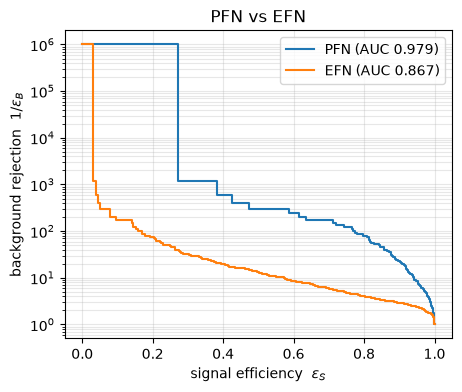

In [17]:
# Compare PFN vs EFN on the same test set.
res_efn = evaluate(efn, efn_loaders["test"], kind="efn")
print(f"PFN  AUC = {res_pfn['auc']:.4f}")
print(f"EFN  AUC = {res_efn['auc']:.4f}   (IRC-safe; uses only angles + energy fractions)")

plt.figure(figsize=(5, 4))
for res, lbl in [(res_pfn, "PFN"), (res_efn, "EFN")]:
    fpr, tpr, _ = roc_curve(res["y"], res["p"])
    plt.plot(tpr, 1.0 / np.clip(fpr, 1e-6, 1), label=f"{lbl} (AUC {res['auc']:.3f})")
plt.yscale("log"); plt.xlabel("signal efficiency  $\\epsilon_S$")
plt.ylabel("background rejection  $1/\\epsilon_B$")
plt.grid(True, which="both", alpha=0.3); plt.legend(); plt.title("PFN vs EFN"); plt.show()

### Demonstrating IRC safety

We take one real top jet and apply the two "harmless" deformations, then watch each model's predicted
$p(\text{top})$. The **EFN output should barely move** (it is invariant *by construction*); the **PFN has no
such guarantee** and can shift, because it feeds every particle's $p_T$/$E$ through $\Phi$.

In [18]:
# ========================================================================================
# SINGLE-JET EVALUATION HELPERS
# ========================================================================================

# @torch.no_grad() disables gradient tracking to save memory, as we are only evaluating.
@torch.no_grad()
def pfn_prob(pt, e, deta, dphi):
    # Convert raw python lists/arrays into standard numpy arrays for vectorized math.
    pt, e, deta, dphi = map(np.asarray, (pt, e, deta, dphi))

    # Re-calculate the spatial distance feature: dR = sqrt(deta^2 + dphi^2)
    dR = np.sqrt(deta**2 + dphi**2)

    # Re-engineer the exact same 7 features used during training.
    # We add 1e-8 to the logarithms to prevent log(0) -> NaN crashes.
    feats = np.stack(
        [
            deta,
            dphi,
            np.log(pt + 1e-8),
            np.log(e + 1e-8),
            np.log(pt / pt.sum() + 1e-8),
            np.log(e / e.sum() + 1e-8),
            dR,
        ],
        axis=-1,
    ).astype(np.float32)

    # 1. torch.from_numpy(feats) converts the 2D array (N_particles, 7_features) to a tensor.
    # 2. [None] is a NumPy/PyTorch indexing trick (equivalent to unsqueeze(0)).
    #    It adds a dummy Batch dimension, making the shape (1, N_particles, 7) so the model can read it.
    # 3. We standardize the features using the feat_mean and feat_std calculated ONLY from the training set.
    x = (torch.from_numpy(feats)[None] - feat_mean) / feat_std

    # Create a mask of pure 1.0s. Since we are evaluating a single, raw, unpadded jet,
    # every single particle in this tensor is "real". Shape: (1, N_particles).
    m = torch.ones(1, x.shape[1])

    # Pass the tensor and mask through the Particle Flow Network (PFN).
    # F.softmax(..., -1) converts the raw [-inf, inf] output logits into [0, 1] probabilities.
    # [0, 1] extracts the first batch (index 0) and the probability for the Top Quark (class index 1).
    return F.softmax(pfn(x.to(device), m.to(device)), -1)[0, 1].item()


@torch.no_grad()
def efn_prob(pt, e, deta, dphi):
    # The Energy Flow Network (EFN) requires completely different, raw inputs.
    pt = np.asarray(pt)

    # Calculate 'z', the linear transverse momentum fraction: z = pT / sum(pT)
    z = (pt / pt.sum()).astype(np.float32)

    # Stack only the raw spatial angles (deta, dphi) and add the dummy Batch dimension via [None].
    a = torch.from_numpy(
        np.stack([np.asarray(deta), np.asarray(dphi)], axis=-1).astype(np.float32)
    )[None]

    # Create the pure 1.0s mask for the unpadded jet.
    m = torch.ones(1, a.shape[1])

    # Pass angles (a), energy fractions (z), and the mask (m) into the EFN.
    # Extract and return the Top Quark probability.
    return F.softmax(
        efn(a.to(device), torch.from_numpy(z)[None].to(device), m.to(device)), -1
    )[0, 1].item()


# ========================================================================================
# PHYSICS PERTURBATIONS (TESTING IRC SAFETY)
# ========================================================================================


def collinear_split(pt, e, eta, phi, k):
    """
    Simulates a Collinear Split: A single particle at index 'k' spontaneously splits
    into two identical particles moving in the exact same trajectory.
    According to the laws of quantum chromodynamics (QCD), this should NOT change
    the fundamental physics or classification of the jet.
    """
    # np.delete removes the original particle 'k' from the array.
    # np.append adds TWO new particles to the end of the array.
    # The new particles have exactly half the momentum (pt[k]/2) and half the energy (e[k]/2),
    # but their spatial angles (eta, phi) remain perfectly identical to the original.
    return (
        np.append(np.delete(pt, k), [pt[k] / 2, pt[k] / 2]),
        np.append(np.delete(e, k), [e[k] / 2, e[k] / 2]),
        np.append(np.delete(eta, k), [eta[k], eta[k]]),
        np.append(np.delete(phi, k), [phi[k], phi[k]]),
    )


def add_soft(pt, e, eta, phi, frac=1e-3):
    """
    Simulates Infrared Radiation: A virtually massless, extremely low-energy ("soft")
    particle is emitted or detected in the jet.
    Because its energy is effectively zero, it should NOT alter the jet's classification.
    """
    # np.append adds a single new particle to the end of the arrays.
    # Its energy/momentum is set to a microscopic fraction (0.1%) of the jet's total.
    # Its angles are arbitrarily set to 0.0 (the center of the jet axis).
    return (
        np.append(pt, pt.sum() * frac),
        np.append(e, e.sum() * frac),
        np.append(eta, 0.0),
        np.append(phi, 0.0),
    )


# Select a single, real Top Quark jet from the dataset to use as our test subject.
j = int(idx_top[0])

# Extract its raw, completely unpadded kinematics directly from the Awkward Arrays.
rpt = ak.to_numpy(np.sqrt(br["part_px"][j] ** 2 + br["part_py"][j] ** 2))
re = ak.to_numpy(br["part_energy"][j])
reta = ak.to_numpy(br["part_deta"][j])
rphi = ak.to_numpy(br["part_dphi"][j])

# Find the index 'k' of the single most energetic particle in the jet to split.
# np.argmax returns the index of the maximum value in the pT array.
k = int(np.argmax(rpt))

# Generate the two mathematically perturbed versions of this jet.
# csp = The jet where the hardest particle was chopped perfectly in half.
# sft = The jet where a microscopic speck of dust was added to the center.
csp = collinear_split(rpt, re, reta, rphi, k)
sft = add_soft(rpt, re, reta, rphi)

# Print the comparison matrix.
# We use Python's *args unpacking (e.g., *csp) to feed the 4 tuples returned by
# the perturbation functions directly into the 4 arguments expected by our _prob functions.
print("                     PFN p(top)   EFN p(top)")

# 1. Baseline: The raw, unaltered jet. Both networks will output a high probability for 'Top'.
print(
    f"baseline             {pfn_prob(rpt, re, reta, rphi):8.4f}   {efn_prob(rpt, re, reta, rphi):8.4f}"
)

# 2. Collinear Split:
# The PFN's probability will wildly change because it relies on non-linear logarithms of particle counts.
# The EFN's probability will stay identical down to the decimal. It mathematically factored out the split
# because z1*Phi + z2*Phi = (z1+z2)*Phi.
print(f"collinear split      {pfn_prob(*csp):8.4f}   {efn_prob(*csp):8.4f}")

# 3. Soft Particle:
# The PFN's probability changes again because the total number of particles (N) increased.
# The EFN's probability stays identical. The new particle has z ≈ 0, so its weight (w * h) evaluates
# to exactly 0 and contributes nothing to the sum.
print(f"soft particle added  {pfn_prob(*sft):8.4f}   {efn_prob(*sft):8.4f}")

print("\nEFN columns should be essentially constant (IRC-safe by construction);")
print("the PFN has no such guarantee.")


                     PFN p(top)   EFN p(top)
baseline               0.9935     0.9097
collinear split        0.9942     0.9097
soft particle added    0.9935     0.9094

EFN columns should be essentially constant (IRC-safe by construction);
the PFN has no such guarantee.


## 8 · Exercises

1. **Pooling matters.** Re-train the warm-up classifier with `pool="mean"`. Then construct two point clouds
   that `mean`-pooling cannot tell apart but `sum`-pooling can (hint: duplicate every point). What does this
   say about the Deep Sets theorem's preference for the sum?
2. **Jet-mass regression.** Replace the classifier head with a single regression output and train the PFN to
   predict the jet (soft-drop) mass. Use an MSE loss; report the resolution. Which features matter most?
3. **Multiclass.** Extend from top-vs-QCD to the full set of JetClass labels (QCD, H, W/Z, top). Plot a
   confusion matrix. Which classes are confused, and does that make physical sense?
4. **How IRC-safe is the PFN in practice?** Sweep the collinear/soft deformation strength and plot how far
   each model's output drifts. The EFN is flat by construction — by how much does the trained PFN move?
5. **Attention pooling (teaser for Module 3).** Replace `masked_sum` with a learned attention-weighted sum
   $\sum_i \alpha_i\, \phi(x_i)$ where $\alpha_i = \mathrm{softmax}_i(w^\top \phi(x_i))$. Does it help? You have
   just built a (very small) Set Transformer pooling layer.

## 9 · Recap, and the bridge to Module 2

- A jet is a **set**; the right inductive bias is **permutation invariance**.
- **Deep Sets**: embed each particle with $\phi$, **pool** (sum/mean), decode with $\rho$. The pool is the
  invariant **aggregation** — the atom we will reuse for the rest of the course.
- **PFN** = Deep Sets on particle features. **EFN** = the IRC-safe variant that pools angles weighted by
  energy fractions — a *physics guarantee written into the architecture*.
- We evaluated like physicists: **ROC / AUC** and **background rejection at fixed signal efficiency**.

**What's missing?** DeepSets treats every particle *independently* before pooling — it never lets two
particles "talk". But jet substructure is all about *relations* between particles (prongs, subjets, angles
between hard emissions). In **Module 2** we add the next ingredient — **edges** — turning the set into a
**graph** and the pool into **message passing** (EdgeConv, ParticleNet). Everything you built here carries
straight over: the neighbourhood aggregation in a GNN is exactly a small DeepSet.